<center><h1>Chong_Xie_HW2</h1></center>
<br>
<br>

Name: Chong Xie
<br>
USC ID: 6800668300

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
import itertools
import statsmodels.api as sm

Get the Cycle Power Plant Data Set

In [2]:
import pandas as pd

df = pd.read_excel('../data/CCPP/Folds5x2_pp.xlsx', sheet_name='Sheet1')

### (b) Exploring the data

#### i. rows and columns

In [3]:
display(df.head(5))
print(df.shape)
print('There are {} rows and {} columns in the dataset.'.format(df.shape[0], df.shape[1]))

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


(9568, 5)
There are 9568 rows and 5 columns in the dataset.


There are 9568 rows and 5 columns in the dataset. The rows represent data points of the power plant that contain hourly average ambient variables Temperature (AT), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V) to predict the net hourly electrical energy output (EP, PE in this dataset). The columns represent the features above.

#### ii. pairwise scatterplots of all the varianbles

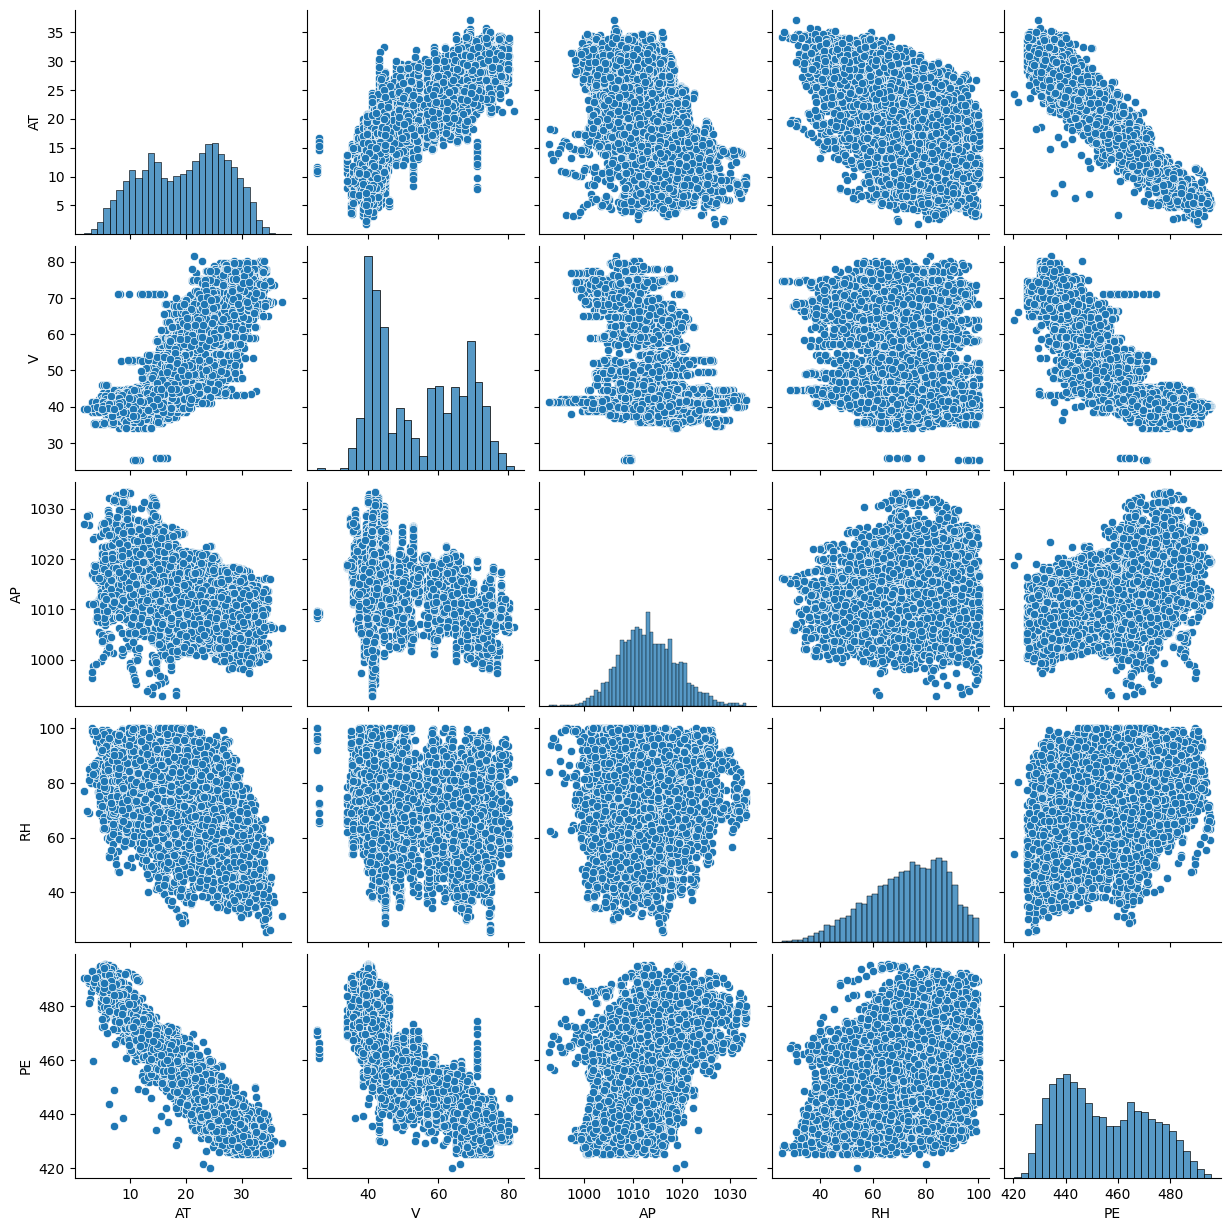

In [4]:
sns.pairplot(data=df)
plt.show()

From the plots, I found that:
- AT and V have strong negative relation with PE.
- AT has a positive relation with V.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
df.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


### (c) Simple Linear Regression

/var/folders/sg/_895cnkd62nbv7z85l0jtpcw0000gn/T/ipykernel_2006/3680095413.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  simple_lr_parameters.append((predictor, model.params[0], model.params[1], model.rsquared, model.pvalues[predictor]))
/var/folders/sg/_895cnkd62nbv7z85l0jtpcw0000gn/T/ipykernel_2006/3680095413.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Slope: {model.params[1]:.4f}")


Model: PE ~ AT
Intercept: 497.0341
Slope: -2.1713
R^2: 0.8989
p-value for slope: 0.00000e+00
Conclusion: statistically significant association


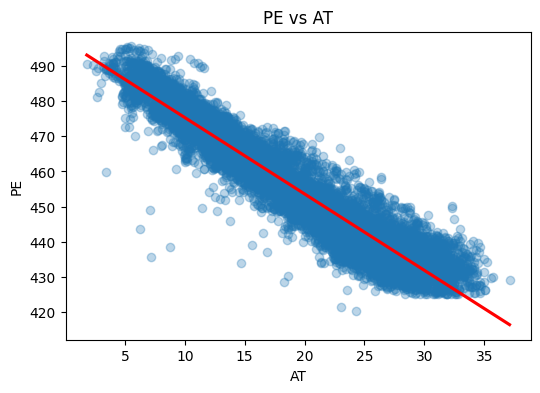

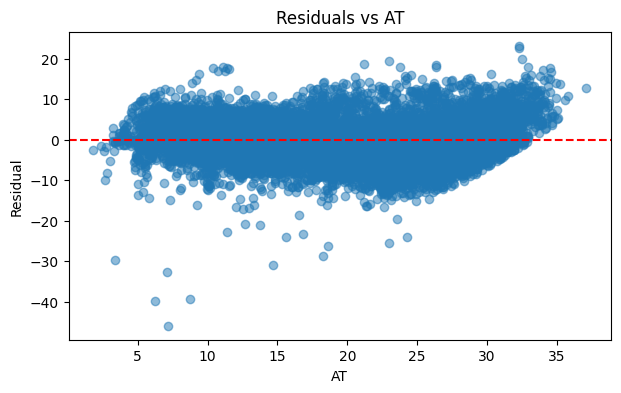

/var/folders/sg/_895cnkd62nbv7z85l0jtpcw0000gn/T/ipykernel_2006/3680095413.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  simple_lr_parameters.append((predictor, model.params[0], model.params[1], model.rsquared, model.pvalues[predictor]))
/var/folders/sg/_895cnkd62nbv7z85l0jtpcw0000gn/T/ipykernel_2006/3680095413.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Slope: {model.params[1]:.4f}")


Model: PE ~ V
Intercept: 517.8015
Slope: -1.1681
R^2: 0.7565
p-value for slope: 0.00000e+00
Conclusion: statistically significant association


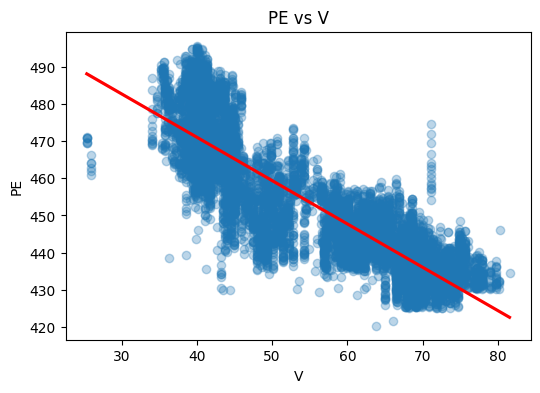

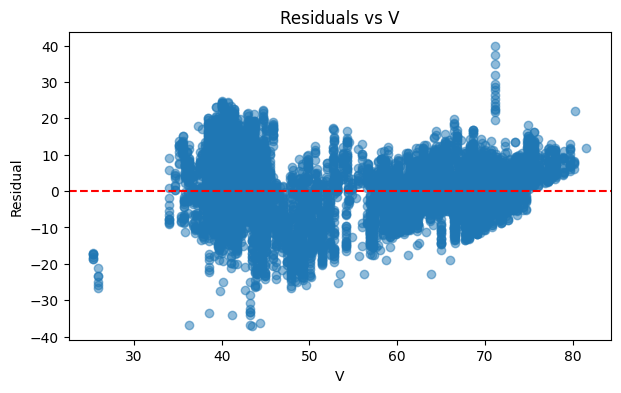

/var/folders/sg/_895cnkd62nbv7z85l0jtpcw0000gn/T/ipykernel_2006/3680095413.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  simple_lr_parameters.append((predictor, model.params[0], model.params[1], model.rsquared, model.pvalues[predictor]))
/var/folders/sg/_895cnkd62nbv7z85l0jtpcw0000gn/T/ipykernel_2006/3680095413.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Slope: {model.params[1]:.4f}")


Model: PE ~ AP
Intercept: -1055.2610
Slope: 1.4899
R^2: 0.2688
p-value for slope: 0.00000e+00
Conclusion: statistically significant association


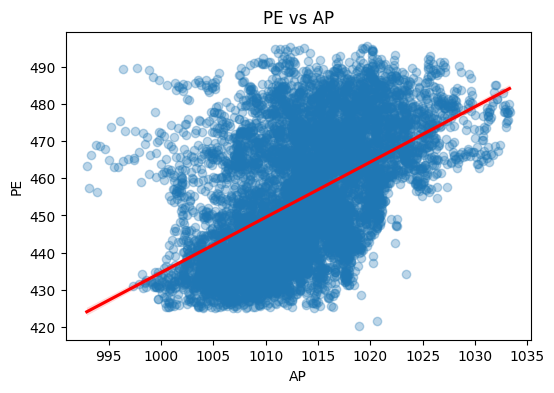

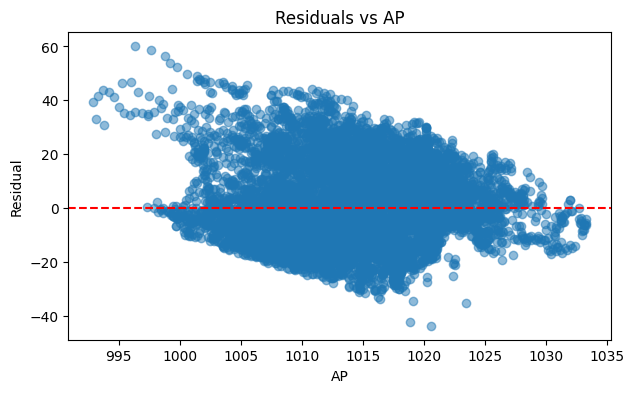

/var/folders/sg/_895cnkd62nbv7z85l0jtpcw0000gn/T/ipykernel_2006/3680095413.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  simple_lr_parameters.append((predictor, model.params[0], model.params[1], model.rsquared, model.pvalues[predictor]))
/var/folders/sg/_895cnkd62nbv7z85l0jtpcw0000gn/T/ipykernel_2006/3680095413.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Slope: {model.params[1]:.4f}")


Model: PE ~ RH
Intercept: 420.9618
Slope: 0.4557
R^2: 0.1519
p-value for slope: 0.00000e+00
Conclusion: statistically significant association


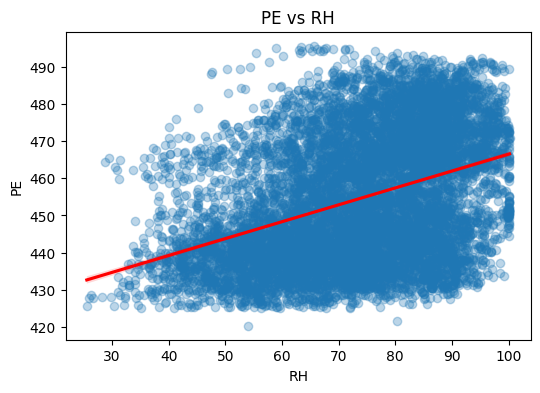

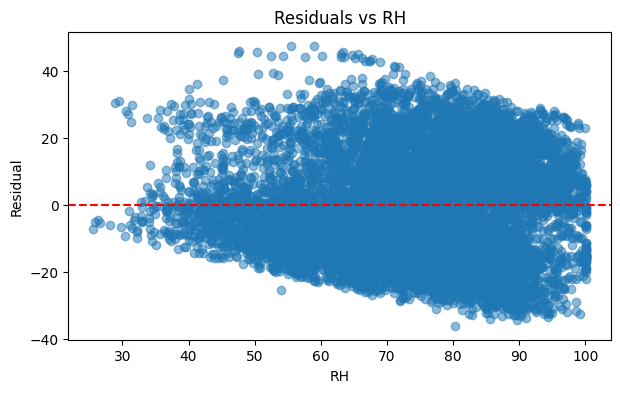

In [6]:
resp = 'PE'
simple_lr_parameters = []

for predictor in ['AT', 'V', 'AP', 'RH']:
    X = df[predictor]
    y = df[resp]
    
    # add constant for the beta0 constant in the linear regression model
    model = sm.OLS(y, sm.add_constant(X)).fit()
    residuals = model.resid

    simple_lr_parameters.append((predictor, model.params[0], model.params[1], model.rsquared, model.pvalues[predictor]))

    print(f"Model: {resp} ~ {predictor}")
    print(f"Intercept: {model.params['const']:.4f}")
    print(f"Slope: {model.params[1]:.4f}")
    print(f"R^2: {model.rsquared:.4f}")
    print(f"p-value for slope: {model.pvalues[predictor]:.5e}")
    
    if model.pvalues[predictor] < 0.05:
        print("Conclusion: statistically significant association")
    else:
        print("Conclusion: not statistically significant")
    
    # scatter plot + fitted line
    plt.figure(figsize=(6, 4))
    sns.regplot(x=df[predictor], y=df[resp], scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
    plt.title(f"{resp} vs {predictor}")
    plt.xlabel(predictor)
    plt.ylabel(resp)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.scatter(df[predictor], residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f"Residuals vs {predictor}")
    plt.xlabel(predictor)
    plt.ylabel("Residual")
    plt.show()

Residuals:

- AT (Temperatures): There are a few outliers in the lower-left of the graph, between 5 and 10.
- V (Exhaust Vaccum): There are some outliers in the lower-left and upper-right of the graph.
- AP (Ambient Pressure): There are some outliers in the upper-left of the graph.
- RH (Relative Humidity): On both right and left side of the graph, there are outliers.

### (d) Multiple Regression

In [7]:
X = df[['AT', 'V', 'AP', 'RH']]
model = sm.OLS(df[resp], sm.add_constant(X)).fit()
multi_parameters = model.params[1:]
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Wed, 16 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:31:28   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.000     435.500     473.718
AT            -1.9775      0.015   -129.342      0.000      -2.007      -1.948
V             -0.2339      0.007    -32.122      0.000      -0.248      -0.220
AP             0.0621      0.009      6.564      0.000       0.044       0.081
RH            -0.1581      0.004    -37.918      0.000      -0.166      -0.150
==============================================================================
Omnibus:                      892.002   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4086.777
Skew:                          -0.352   Prob(JB):                         0.00
Kurtosis:                       6.123   Cond. No.                     2.13e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.13e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Observation:

For all the predictors, we **can** reject the null hypothesis $H_0: \beta_j = 0$ as the p values are 0 (less than 0.05)

### (e) 1c Compare to 1d

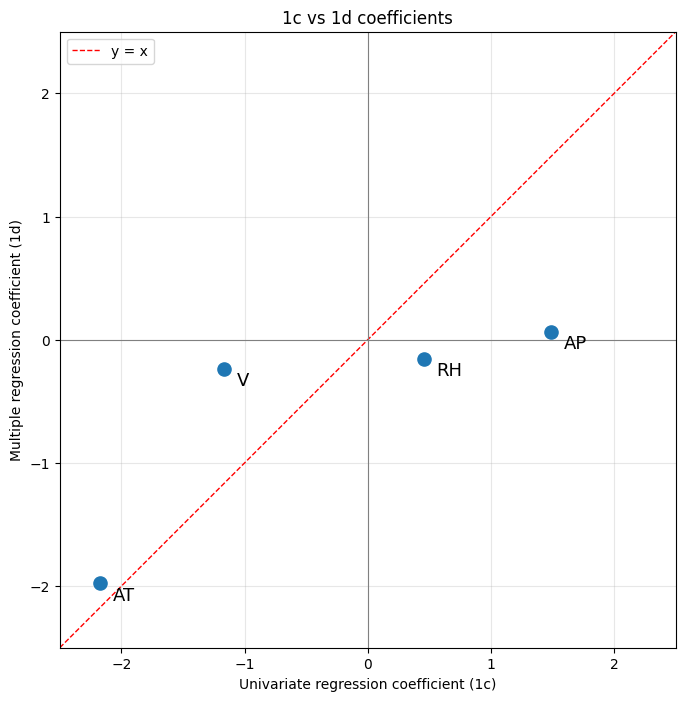

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))

for name, _, slope, _, _ in simple_lr_parameters:
    ax.scatter(slope, multi_parameters[name], s=90, color='tab:blue', zorder=3)
    ax.annotate(name, (slope, multi_parameters[name]),
                textcoords='offset points', xytext=(9, -12), fontsize=13)

lim = [-2.5, 2.5]
ax.plot(lim, lim, 'r--', lw=1, label='y = x')
ax.axhline(0, color='grey', lw=0.8)
ax.axvline(0, color='grey', lw=0.8)

ax.set_xlim(*lim)
ax.set_ylim(*lim)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('Univariate regression coefficient (1c)')
ax.set_ylabel('Multiple regression coefficient (1d)')
ax.set_title('1c vs 1d coefficients')
ax.grid(alpha=0.3)
ax.legend()
plt.show()

Observations:
- For AT, the univariate coeff is close to the multi coeff.
- For V, the multi coeff is higher than univariate coeff.
- For RH and AP, the multi coeff is lower than univariate coeff.

### (f) Nonlinear Association

Model: PE ~ AT + AT^2 + AT^3
R^2: 0.9119 (linear: 0.8989)
p-value for X^2: 8.83305e-73
p-value for X^3: 3.65218e-110
Conclusion: evidence of nonlinear association


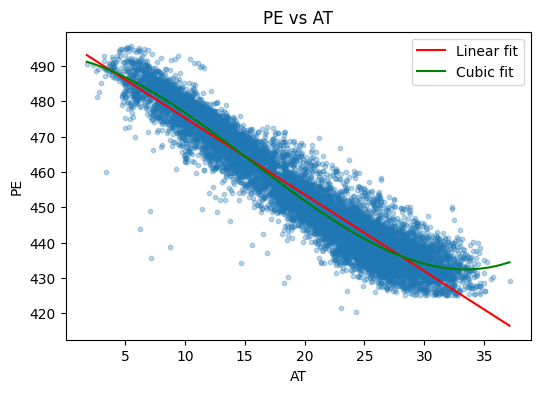

Model: PE ~ V + V^2 + V^3
R^2: 0.7750 (linear: 0.7565)
p-value for X^2: 7.68497e-01
p-value for X^3: 1.37349e-02
Conclusion: evidence of nonlinear association


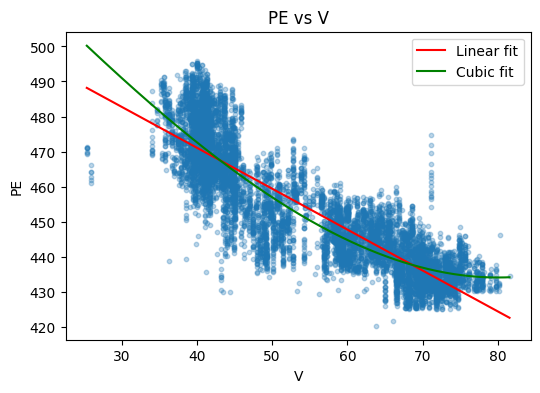

Model: PE ~ AP + AP^2 + AP^3
R^2: 0.2749 (linear: 0.2688)
p-value for X^2: 3.66670e-17
p-value for X^3: 8.26415e-18
Conclusion: evidence of nonlinear association


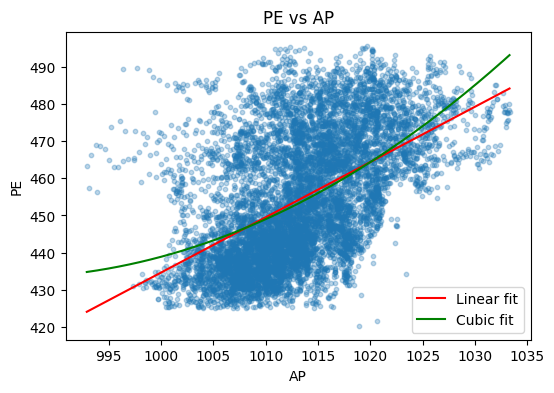

Model: PE ~ RH + RH^2 + RH^3
R^2: 0.1537 (linear: 0.1519)
p-value for X^2: 9.39543e-06
p-value for X^3: 1.44028e-05
Conclusion: evidence of nonlinear association


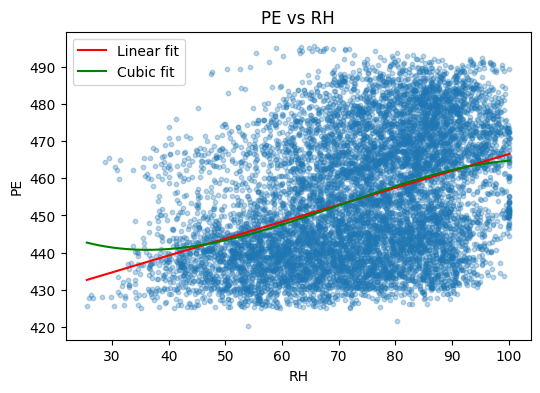

In [9]:
resp = 'PE'
nonlinear_parameters = []

for predictor in ['AT', 'V', 'AP', 'RH']:
    X = pd.DataFrame({
        'X':  df[predictor],
        'X2': df[predictor] ** 2,
        'X3': df[predictor] ** 3
    })
    y = df[resp]

    model = sm.OLS(y, sm.add_constant(X)).fit()
    linear_model = sm.OLS(y, sm.add_constant(df[[predictor]])).fit()

    nonlinear_parameters.append((predictor, linear_model.rsquared, model.rsquared,
                                 model.pvalues['X2'], model.pvalues['X3']))

    print(f"Model: {resp} ~ {predictor} + {predictor}^2 + {predictor}^3")
    print(f"R^2: {model.rsquared:.4f} (linear: {linear_model.rsquared:.4f})")
    print(f"p-value for X^2: {model.pvalues['X2']:.5e}")
    print(f"p-value for X^3: {model.pvalues['X3']:.5e}")

    if model.pvalues['X2'] < 0.05 or model.pvalues['X3'] < 0.05:
        print("Conclusion: evidence of nonlinear association")
    else:
        print("Conclusion: no evidence of nonlinear association")

    # scatter plot + linear fit vs cubic fit
    x_grid = np.linspace(df[predictor].min(), df[predictor].max(), 200)
    grid = sm.add_constant(pd.DataFrame({'X': x_grid, 'X2': x_grid ** 2, 'X3': x_grid ** 3}))
    cubic_line  = model.predict(grid)
    linear_line = linear_model.predict(sm.add_constant(pd.DataFrame({predictor: x_grid})))

    plt.figure(figsize=(6, 4))
    plt.scatter(df[predictor], df[resp], alpha=0.3, s=10)
    plt.plot(x_grid, linear_line, color='red', label='Linear fit')
    plt.plot(x_grid, cubic_line, color='green', label='Cubic fit')
    plt.title(f"{resp} vs {predictor}")
    plt.xlabel(predictor)
    plt.ylabel(resp)
    plt.legend()
    plt.show()

### (g) Interactions of Predictors

In [15]:
X = df[["AT", "V", "AP", "RH"]]
poly = sklearn.preprocessing.PolynomialFeatures(interaction_only=True)
X_poly = pd.DataFrame(
    poly.fit_transform(X),
    columns=poly.get_feature_names_out(X.columns),
    index=X.index
)
y = df[resp]

mod = sm.OLS(y, X_poly)
res = mod.fit()
    
# Display model summary
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Wed, 16 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:52:28   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
1            685.7825     78.640      8.721      0.0

In [16]:
poly.get_feature_names_out()

array(['1', 'AT', 'V', 'AP', 'RH', 'AT V', 'AT AP', 'AT RH', 'V AP',
       'V RH', 'AP RH'], dtype=object)

Observations:
Here AT V / AT RH / V AP / AP RH are the interaction terms that are statistically significant.

### (h) Improvement

### (i) KNN

### (j ) Compare KNN and Linear

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

### (c) The relationship between the predictors and response is highly non-linear.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

### (b) What is our prediction with K = 1? Why?

### (c) What is our prediction with K = 3? Why?

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?